# Online Retail Data Analysis: RFM, CLV, and Time Series Forecasting

## 1. Data Download

This section downloads the 'Online Retail II' dataset from Kaggle Hub, providing access to the raw transaction data for analysis.

In [1]:
import kagglehub

# Define the dataset identifier from the provided URL
dataset_id = 'mashlyn/online-retail-ii-uci'

# Download the dataset using kagglehub
# This will download the dataset to a local path, typically in ~/.kaggle/kagglehub
local_path = kagglehub.dataset_download(dataset_id)

print(f"Dataset '{dataset_id}' downloaded to: {local_path}")

Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.
Dataset 'mashlyn/online-retail-ii-uci' downloaded to: /kaggle/input/online-retail-ii-uci


The dataset has been downloaded. You can find the files in the directory specified by `local_path` in the output above. You can now use pandas to load the CSV files from this directory.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# List contents of the downloaded directory
print(f"Contents of the downloaded directory: {os.listdir(local_path)}")

csv_files = [f for f in os.listdir(local_path) if f.endswith('.csv')]

if csv_files:
    # Take the first CSV file found, or modify this logic if a specific file is needed
    csv_file_name = csv_files[0]
    full_csv_path = os.path.join(local_path, csv_file_name)

    print(f"Loading data from: {full_csv_path}")
    df = pd.read_csv(full_csv_path)

    print("First 6 rows of the DataFrame:")
    display(df.head(6))
else:
    print(f"No CSV files found in the downloaded directory: {local_path}")

Contents of the downloaded directory: ['online_retail_II.csv']
Loading data from: /kaggle/input/online-retail-ii-uci/online_retail_II.csv
First 6 rows of the DataFrame:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom


## 2. Initial Data Loading and Inspection

Here, the downloaded CSV file is loaded into a pandas DataFrame. We then inspect the first few rows to understand its structure and content, and check data types and non-null counts using **df.info()**.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


## 3. Data Cleaning and Preprocessing

This crucial step involves cleaning the raw data by:
- Removing rows with missing Customer ID (as it's essential for customer-level analysis).
- Filtering out canceled orders (identified by 'C' in the Invoice number).
- Eliminating transactions with negative or zero 'Quantity' and 'Price' (as these are typically data entry errors or returns).
- Removing duplicate entries to ensure data integrity.

In [ ]:
# Remove rows with missing Customer ID
df = df.dropna(subset=["Customer ID"])

# Remove canceled orders (Invoice starting with 'C')
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# Remove negative quantities
df = df[df["Quantity"] > 0]

# Remove negative or zero prices
df = df[df["Price"] > 0]

# Remove duplicates
df = df.drop_duplicates()

## 4. Feature Engineering: Total Price and Date Conversion

We create a new feature, **TotalPrice**, by multiplying **Quantity** and **Price**. The InvoiceDate column is converted to datetime objects to enable time-based calculations, and a 'reference_date' is established for calculating recency.

In [ ]:
df["TotalPrice"] = df["Quantity"] * df["Price"]

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

## 5. RFM (Recency, Frequency, Monetary) Analysis

RFM analysis is a marketing technique used to quantitatively rank and group customers based on their past purchasing behavior. We calculate:
- **Recency**: Days since last purchase.
- **Frequency**: Total number of purchases.
- **Monetary**: Total amount spent.

The 'rfm' DataFrame is then displayed to show the computed values for each customer.

In [ ]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [ ]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,  # Recency
    "Invoice": "nunique",                                      # Frequency
    "TotalPrice": "sum"                                        # Monetary
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head(5)

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


## 6. Scaling RFM Features

Before applying K-Means clustering, the RFM features (Recency, Frequency, Monetary) are scaled using `StandardScaler`. This ensures that features with larger values do not dominate the clustering process.

In [ ]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

## 7. K-Means Clustering for Customer Segmentation

K-Means clustering is applied to the scaled RFM data to identify distinct customer segments. The n_clusters is set to 4, and the resulting cluster assignments are added as a new column, 'Cluster', to the rfm DataFrame.

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

## 8. Visualizing Customer Segments

A scatter plot is generated to visualize the customer segments based on their Recency and Monetary values. Each point represents a customer, colored according to their assigned cluster, providing insights into their purchasing patterns.

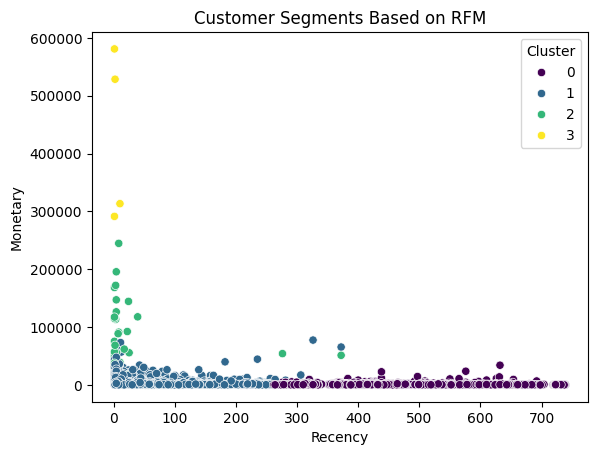

In [ ]:
sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="viridis"
)
plt.title("Customer Segments Based on RFM")
plt.show()

## 9. Customer Lifetime Value (CLV) Prediction

This section focuses on predicting Customer Lifetime Value using a Random Forest Regressor. The RFM features (Recency, Frequency, Monetary) are used as independent variables (X) to predict 'Monetary' (which is assigned to `CLV`) as the dependent variable (y). The data is split into training and testing sets, and the model is trained.

In [ ]:
rfm["CLV"] = rfm["Monetary"]

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["CLV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

## 10. Evaluating CLV Predictions

The trained Random Forest Regressor is used to predict CLV on the test set. A scatter plot compares the actual CLV values against the predicted CLV values, visually assessing the model's performance.

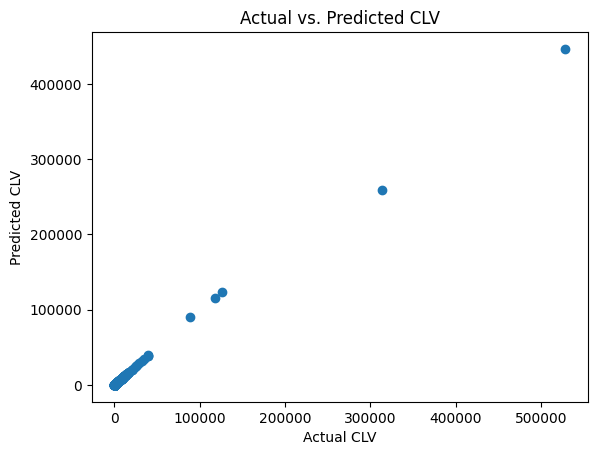

In [ ]:
y_preds = model.predict(X_test)

plt.scatter(y_test, y_preds)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs. Predicted CLV")
plt.show()

## 11. Quantifying CLV Model Performance

To quantitatively evaluate the CLV prediction model, Mean Absolute Error (MAE) and R-squared (R2) score are calculated. These metrics provide insight into the model's accuracy and how well it explains the variance in CLV.

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_preds)
r2 = r2_score(y_test, y_preds)

mae, r2

(125.77570442176922, 0.9773661455288245)

## 12. Time Series Analysis: Preparing Monthly Sales Data

For time series forecasting, the InvoiceMonth column is created to convert the InvoiceDate column to a monthly period, and the **TotalPrice** is aggregated to calculate total monthly sales. This creates a time series (monthly) suitable for forecasting.

In [ ]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")
monthly = df.groupby("InvoiceMonth")["TotalPrice"].sum()
monthly = monthly.to_timestamp()

## 13. SARIMAX Model for Sales Forecasting

A Seasonal Autoregressive Integrated Moving Average with Exogenous Regressors (SARIMAX) model is applied to the monthly sales data. The model is fitted with specified order and seasonal order parameters, and then used to forecast sales for the next 12 months.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(monthly, order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit()
forecast = model_fit.forecast(12)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 14. Visualizing Historical and Forecasted Sales

Finally, a plot is generated to visualize both the historical monthly sales and the forecasted sales from the SARIMAX model. This allows for a clear comparison and understanding of past trends and future predictions.

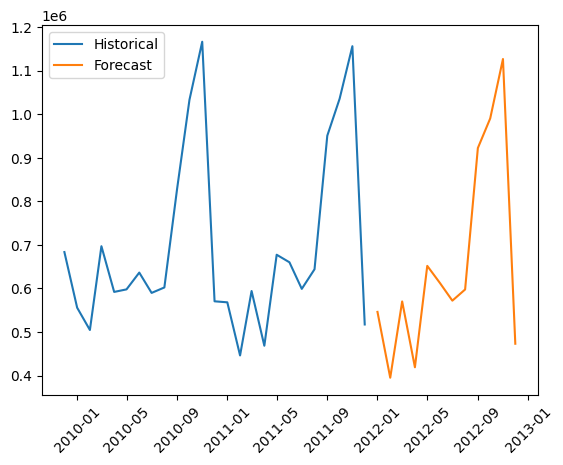

In [ ]:
plt.plot(monthly, label="Historical")
plt.plot(forecast, label="Forecast")
plt.xticks(rotation=45)
plt.legend()
plt.show()